In [1]:
import os
import json
import time
import zipfile
import datetime
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import stats
from scipy.interpolate import LinearNDInterpolator
from scipy.stats import kurtosis, skew
from scipy.ndimage import label, find_objects
from skimage import measure
import pywt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingWarmRestarts
from torchvision import transforms

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

%matplotlib inline

In [2]:
class Utility:
    @staticmethod
    def add_noise(data, mask, ng, pixel_size=2.):
        return data + np.random.randn(*data.shape) * 0.4 / (2*ng*pixel_size**2)**0.5 * mask
    
    @staticmethod
    def load_np(data_dir, file_name):
        return np.load(os.path.join(data_dir, file_name))

    @staticmethod
    def save_np(data_dir, file_name, data):
        np.save(os.path.join(data_dir, file_name), data)

    @staticmethod
    def save_json_zip(submission_dir, json_file_name, zip_file_name, data):
        os.makedirs(submission_dir, exist_ok=True)
        json_path = os.path.join(submission_dir, json_file_name)
        with open(json_path, "w") as f:
            json.dump(data, f)
        zip_path = os.path.join(submission_dir, zip_file_name)
        with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
            zf.write(json_path, arcname=json_file_name)
        os.remove(json_path)
        return zip_path


class Data:
    def __init__(self, data_dir, USE_PUBLIC_DATASET):
        self.USE_PUBLIC_DATASET = USE_PUBLIC_DATASET
        self.data_dir = data_dir
        self.mask_file = 'WIDE12H_bin2_2arcmin_mask.npy'
        self.viz_label_file = 'label.npy'
        
        if self.USE_PUBLIC_DATASET:
            self.kappa_file = 'WIDE12H_bin2_2arcmin_kappa.npy'
            self.label_file = self.viz_label_file
            self.Ncosmo = 101
            self.Nsys = 256
            self.test_kappa_file = 'WIDE12H_bin2_2arcmin_kappa_noisy_test.npy'
            self.Ntest = 4000
        else:
            self.kappa_file = 'sampled_WIDE12H_bin2_2arcmin_kappa.npy'
            self.label_file = 'sampled_label.npy'
            self.Ncosmo = 3
            self.Nsys = 30
            self.test_kappa_file = 'sampled_WIDE12H_bin2_2arcmin_kappa_noisy_test.npy'
            self.Ntest = 3
        
        self.shape = [1424, 176]
        self.pixelsize_arcmin = 2
        self.pixelsize_radian = self.pixelsize_arcmin / 60 / 180 * np.pi
        self.ng = 30

    def load_train_data(self):
        self.mask = Utility.load_np(data_dir=self.data_dir, file_name=self.mask_file)
        self.kappa = np.zeros((self.Ncosmo, self.Nsys, *self.shape), dtype=np.float16)
        self.kappa[:,:,self.mask] = Utility.load_np(data_dir=self.data_dir, file_name=self.kappa_file)
        self.label = Utility.load_np(data_dir=self.data_dir, file_name=self.label_file)
        self.viz_label = Utility.load_np(data_dir=self.data_dir, file_name=self.viz_label_file)

    def load_test_data(self):
        self.kappa_test = np.zeros((self.Ntest, *self.shape), dtype=np.float16)
        self.kappa_test[:,self.mask] = Utility.load_np(data_dir=self.data_dir, file_name=self.test_kappa_file)


class Score:
    @staticmethod
    def _score_phase1(true_cosmo, infer_cosmo, errorbar):
        sq_error = (true_cosmo - infer_cosmo)**2
        scale_factor = 1000
        score = - np.sum(sq_error / errorbar**2 + np.log(errorbar**2) + scale_factor * sq_error, 1)
        score = np.mean(score)
        return score if score >= -10**6 else -10**6

In [16]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out


class MultiScaleResNet(nn.Module):
    def __init__(self, height, width, feature_dim=256, dropout=0.3):
        super(MultiScaleResNet, self).__init__()
        
        self.initial = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        
        self.avgpool1 = nn.AdaptiveAvgPool2d((1, 1))
        self.avgpool2 = nn.AdaptiveAvgPool2d((1, 1))
        self.avgpool3 = nn.AdaptiveAvgPool2d((1, 1))
        self.avgpool4 = nn.AdaptiveAvgPool2d((1, 1))
        
        self.fc = nn.Sequential(
            nn.Linear(64 + 128 + 256 + 512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
    def _make_layer(self, in_channels, out_channels, blocks, stride):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride, downsample))
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.initial(x)
        
        x1 = self.layer1(x)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)
        
        f1 = self.avgpool1(x1).view(x1.size(0), -1)
        f2 = self.avgpool2(x2).view(x2.size(0), -1)
        f3 = self.avgpool3(x3).view(x3.size(0), -1)
        f4 = self.avgpool4(x4).view(x4.size(0), -1)
        
        multi_scale = torch.cat([f1, f2, f3, f4], dim=1)
        features = self.fc(multi_scale)
        
        return features


class MultiScaleResNetWithHead(nn.Module):
    def __init__(self, height, width, num_targets, feature_dim=256, dropout=0.3):
        super(MultiScaleResNetWithHead, self).__init__()
        self.feature_extractor = MultiScaleResNet(height, width, feature_dim, dropout)
        self.prediction_head = nn.Linear(feature_dim, num_targets)
        
    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        if return_features:
            return features
        predictions = self.prediction_head(features)
        return predictions
    
    def get_feature_extractor(self):
        return self.feature_extractor

In [20]:
def compute_power_spectrum_features(images, mask, n_bins=50):
    """
    Compute power spectrum features from images using FFT.
    Args:
        images: numpy array of shape (N, H, W)
        mask: boolean mask of shape (H, W)
        n_bins: number of angular scale bins
    Returns:
        features: numpy array of shape (N, n_bins)
    """
    N = images.shape[0]
    features_list = []
    
    # Angular scales in arcminutes
    theta_min = 2.0  # pixel size
    theta_max = 100.0  # maximum scale
    theta_bins = np.logspace(np.log10(theta_min), np.log10(theta_max), n_bins+1)
    
    for i in range(N):
        img = images[i].astype(np.float32).copy()
        img[~mask] = 0  # Apply mask
        
        # Compute 2D FFT
        fft = np.fft.fft2(img)
        power_spectrum = np.abs(fft)**2
        
        # Shift zero frequency to center
        power_spectrum = np.fft.fftshift(power_spectrum)
        
        # Get frequency coordinates
        h, w = power_spectrum.shape
        y_freq = np.fft.fftfreq(h) * (180*60/np.pi) / theta_min  # Convert to arcmin^-1
        x_freq = np.fft.fftfreq(w) * (180*60/np.pi) / theta_min
        
        Y, X = np.meshgrid(y_freq, x_freq, indexing='ij')
        ell = np.sqrt(X**2 + Y**2)  # Angular wavenumber
        
        # Bin power spectrum
        power_bins = []
        for j in range(n_bins):
            mask_bin = (ell >= theta_bins[j]) & (ell < theta_bins[j+1])
            if np.sum(mask_bin) > 0:
                power_bins.append(np.mean(power_spectrum[mask_bin]))
            else:
                power_bins.append(0.0)
        
        features_list.append(power_bins)
    
    return np.array(features_list, dtype=np.float32)


def compute_peak_statistics_features(images, mask, n_features=20):
    """
    Compute peak statistics features from images.
    Args:
        images: numpy array of shape (N, H, W)
        mask: boolean mask of shape (H, W)
        n_features: number of features to extract
    Returns:
        features: numpy array of shape (N, n_features)
    """
    N = images.shape[0]
    features_list = []
    
    for i in range(N):
        img = images[i].astype(np.float32).copy()
        img_flat = img[mask].flatten()
        
        if len(img_flat) == 0:
            features_list.append(np.zeros(n_features))
            continue
        
        # Basic statistics
        mean_val = np.mean(img_flat)
        std_val = np.std(img_flat)
        
        # Find peaks (local maxima)
        from scipy.ndimage import maximum_filter
        local_max = maximum_filter(img, size=3) == img
        peaks = img[local_max & mask]
        
        if len(peaks) == 0:
            peak_features = np.zeros(18)
        else:
            # Peak statistics
            peak_features = [
                len(peaks),  # number of peaks
                np.mean(peaks),  # mean peak height
                np.std(peaks),  # std peak height
                np.max(peaks),  # max peak height
                np.min(peaks),  # min peak height
                skew(peaks),  # skewness of peaks
                kurtosis(peaks),  # kurtosis of peaks
                np.percentile(peaks, 25),  # 25th percentile
                np.percentile(peaks, 50),  # median
                np.percentile(peaks, 75),  # 75th percentile
                # Spatial distribution
                np.mean(np.where(local_max & mask)[0]),  # mean row position
                np.std(np.where(local_max & mask)[0]),   # std row position
                np.mean(np.where(local_max & mask)[1]),  # mean col position
                np.std(np.where(local_max & mask)[1]),   # std col position
                # Relative to background
                np.mean(peaks) / std_val if std_val > 0 else 0,
                np.max(peaks) / std_val if std_val > 0 else 0,
                len(peaks) / len(img_flat),  # peak density
                np.sum(peaks > mean_val + 2*std_val)  # number of high peaks
            ]
        
        features_list.append(peak_features)
    
    return np.array(features_list, dtype=np.float32)


def compute_minkowski_functionals(images, mask, n_thresholds=12):
    """
    Compute Minkowski functionals from images.
    Args:
        images: numpy array of shape (N, H, W)
        mask: boolean mask of shape (H, W)
        n_thresholds: number of threshold levels
    Returns:
        features: numpy array of shape (N, n_thresholds * 3)
    """
    N = images.shape[0]
    features_list = []
    
    for i in range(N):
        img = images[i].astype(np.float32).copy()
        img_flat = img[mask].flatten()
        
        if len(img_flat) == 0:
            features_list.append(np.zeros(n_thresholds * 3))
            continue
        
        # Define thresholds
        thresholds = np.linspace(np.min(img_flat), np.max(img_flat), n_thresholds)
        
        mf_features = []
        for thresh in thresholds:
            # Binarize image
            binary = (img >= thresh) & mask
            
            # Compute Minkowski functionals
            if np.sum(binary) == 0:
                mf_features.extend([0, 0, 0])
                continue
            
            # Area (V0)
            area = np.sum(binary)
            
            # Perimeter (V1) - using morphological operations
            from skimage import morphology
            perimeter = np.sum(morphology.binary_erosion(binary) != binary)
            
            # Euler characteristic (V2) - holes and connected components
            labeled, n_components = label(binary)
            holes = 0
            for region in find_objects(labeled):
                if region is not None:
                    region_slice = labeled[region]
                    unique_vals = np.unique(region_slice)
                    if len(unique_vals) > 1:  # Has background pixels
                        holes += len(unique_vals) - 1
            
            euler = n_components - holes
            
            mf_features.extend([area, perimeter, euler])
        
        features_list.append(mf_features)
    
    return np.array(features_list, dtype=np.float32)


def compute_wavelet_features(images, mask, n_features=100):
    """
    Compute wavelet coefficient features from images.
    Args:
        images: numpy array of shape (N, H, W)
        mask: boolean mask of shape (H, W)
        n_features: number of features to extract
    Returns:
        features: numpy array of shape (N, n_features)
    """
    N = images.shape[0]
    features_list = []
    
    for i in range(N):
        img = images[i].astype(np.float32).copy()
        img[~mask] = 0
        
        # Use 2D discrete wavelet transform
        coeffs = pywt.dwt2(img, 'haar')
        cA, (cH, cV, cD) = coeffs
        
        # Extract statistics from each coefficient array
        coeff_arrays = [cA, cH, cV, cD]
        wavelet_features = []
        
        for coeff in coeff_arrays:
            flat_coeff = coeff.flatten()
            if len(flat_coeff) > 0:
                wavelet_features.extend([
                    np.mean(flat_coeff),
                    np.std(flat_coeff),
                    skew(flat_coeff),
                    kurtosis(flat_coeff),
                    np.max(flat_coeff),
                    np.min(flat_coeff)
                ])
            else:
                wavelet_features.extend([0] * 6)
        
        # Pad or truncate to n_features
        if len(wavelet_features) < n_features:
            wavelet_features.extend([0] * (n_features - len(wavelet_features)))
        else:
            wavelet_features = wavelet_features[:n_features]
        
        features_list.append(wavelet_features)
    
    return np.array(features_list, dtype=np.float32)


def compute_moment_statistics(images, mask, n_features=30):
    """
    Compute statistical moment features at different scales.
    Args:
        images: numpy array of shape (N, H, W)
        mask: boolean mask of shape (H, W)
        n_features: number of features to extract
    Returns:
        features: numpy array of shape (N, n_features)
    """
    N = images.shape[0]
    features_list = []
    
    # Different spatial scales
    scales = [1, 2, 4, 8, 16]
    
    for i in range(N):
        img = images[i].astype(np.float32).copy()
        img[~mask] = 0
        
        moment_features = []
        
        for scale in scales:
            # Downsample image
            from scipy.ndimage import zoom
            if scale > 1:
                downsampled = zoom(img, 1/scale, order=1)
                down_mask = zoom(mask.astype(float), 1/scale, order=0) > 0.5
            else:
                downsampled = img
                down_mask = mask
            
            flat_img = downsampled[down_mask].flatten()
            
            if len(flat_img) > 0:
                moment_features.extend([
                    np.mean(flat_img),
                    np.std(flat_img),
                    skew(flat_img),
                    kurtosis(flat_img),
                    np.percentile(flat_img, 10),
                    np.percentile(flat_img, 90)
                ])
            else:
                moment_features.extend([0] * 6)
        
        # Pad or truncate
        if len(moment_features) < n_features:
            moment_features.extend([0] * (n_features - len(moment_features)))
        else:
            moment_features = moment_features[:n_features]
        
        features_list.append(moment_features)
    
    return np.array(features_list, dtype=np.float32)


def compute_correlation_functions(images, mask, n_features=30):
    """
    Compute two-point correlation functions.
    Args:
        images: numpy array of shape (N, H, W)
        mask: boolean mask of shape (H, W)
        n_features: number of features to extract
    Returns:
        features: numpy array of shape (N, n_features)
    """
    N = images.shape[0]
    features_list = []
    
    # Angular separations in pixels
    separations = [1, 2, 4, 8, 16, 32]
    
    for i in range(N):
        img = images[i].astype(np.float32).copy()
        img[~mask] = 0
        
        corr_features = []
        
        for sep in separations:
            # Compute correlation at this separation
            corr_sum = 0
            count = 0
            
            h, w = img.shape
            for y in range(sep, h):
                for x in range(sep, w):
                    if mask[y, x] and mask[y-sep, x-sep]:
                        corr_sum += img[y, x] * img[y-sep, x-sep]
                        count += 1
            
            if count > 0:
                corr = corr_sum / count
                corr_features.append(corr)
            else:
                corr_features.append(0)
        
        # Add some derived features
        if len(corr_features) > 1:
            corr_features.extend([
                np.mean(corr_features),  # mean correlation
                np.std(corr_features),   # std correlation
                np.max(corr_features),   # max correlation
                np.min(corr_features),   # min correlation
                np.polyfit(range(len(corr_features)), corr_features, 1)[0] if len(corr_features) > 1 else 0  # slope
            ])
        
        # Pad or truncate
        if len(corr_features) < n_features:
            corr_features.extend([0] * (n_features - len(corr_features)))
        else:
            corr_features = corr_features[:n_features]
        
        features_list.append(corr_features)
    
    return np.array(features_list, dtype=np.float32)

In [5]:
class AugmentedCosmologyDataset(Dataset):
    def __init__(self, data, labels=None, transform=None, augment=False):
        self.data = data
        self.labels = labels
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx].astype(np.float32)
        
        if self.augment:
            if np.random.rand() > 0.5:
                image = np.fliplr(image).copy()
            if np.random.rand() > 0.5:
                image = np.flipud(image).copy()
            k = np.random.randint(0, 2)*2 # only 0 or 180 degrees to preserve shape
            if k > 0:
                image = np.rot90(image, k).copy()
            if np.random.rand() > 0.7:
                noise = np.random.randn(*image.shape) * 0.01
                image = image + noise
        
        if self.transform:
            image = self.transform(image)
            image = image.float()  # Ensure float32 type
        
        if self.labels is not None:
            label = self.labels[idx].astype(np.float32)
            label = torch.from_numpy(label)
            return image, label
        else:
            return image


def train_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0
    pbar = tqdm(dataloader, desc="Training")
    for X, y in pbar:
        X, y = X.to(device), y.to(device)
        pred = model(X, return_features=False)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.6f}'})
    return total_loss / len(dataloader)


def validate_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0
    pbar = tqdm(dataloader, desc="Validating")
    with torch.no_grad():
        for X, y in pbar:
            X, y = X.to(device), y.to(device)
            pred = model(X, return_features=False)
            loss = loss_fn(pred, y)
            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.6f}'})
    return total_loss / len(dataloader)

In [13]:
root_dir = os.getcwd()
USE_PUBLIC_DATASET = True
PUBLIC_DATA_DIR = '../data'
DATA_DIR = PUBLIC_DATA_DIR if USE_PUBLIC_DATASET else os.path.join(root_dir, 'input_data/')

class Config:
    NUM_TARGETS = 2
    CNN_FEATURE_DIM = 256  # Changed from 512 to match saved model
    DROPOUT = 0.35
    BATCH_SIZE = 32
    EPOCHS = 15
    LEARNING_RATE = 5e-4
    WEIGHT_DECAY = 1e-4
    
    # Feature dimensions
    POWER_SPECTRUM_DIM = 50
    PEAK_STATS_DIM = 20
    MINKOWSKI_DIM = 12
    WAVELET_DIM = 100
    MOMENT_DIM = 30
    CORRELATION_DIM = 30
    
    TOTAL_FEATURE_DIM = (CNN_FEATURE_DIM + POWER_SPECTRUM_DIM + PEAK_STATS_DIM + 
                        MINKOWSKI_DIM + WAVELET_DIM + MOMENT_DIM + CORRELATION_DIM)
    
    # Random Forest parameters
    RF_N_ESTIMATORS = 2000
    RF_MAX_FEATURES = 'sqrt'
    
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    CNN_MODEL_PATH = os.path.join(root_dir, "improved_cnn_feature_extractor.pth")
    RF_MODEL_PATH = os.path.join(root_dir, "resnet_rf_model.pkl")
    QRF_MODEL_PATH = os.path.join(root_dir, "resnet_qrf_model.pkl")

config = Config()
print(f"Device: {config.DEVICE}")
print(f"Total feature dimension: {config.TOTAL_FEATURE_DIM}")

Device: cuda
Total feature dimension: 498


In [14]:
data_obj = Data(data_dir=DATA_DIR, USE_PUBLIC_DATASET=USE_PUBLIC_DATASET)
data_obj.load_train_data()
data_obj.load_test_data()

print(f"Train shape: {data_obj.kappa.shape}, Test shape: {data_obj.kappa_test.shape}")

noisy_kappa_train = Utility.load_np(data_dir=DATA_DIR, file_name="noisy_kappa_train.npy")
label_train = Utility.load_np(data_dir=DATA_DIR, file_name="label_train.npy")
noisy_kappa_val = Utility.load_np(data_dir=DATA_DIR, file_name="noisy_kappa_val.npy")
label_val = Utility.load_np(data_dir=DATA_DIR, file_name="label_val.npy")

Ntrain = label_train.shape[0] * label_train.shape[1]
Nval = label_val.shape[0] * label_val.shape[1]

X_train = noisy_kappa_train.reshape(Ntrain, *data_obj.shape)
X_val = noisy_kappa_val.reshape(Nval, *data_obj.shape)
y_train = label_train.reshape(Ntrain, 5)[:, :2]
y_val = label_val.reshape(Nval, 5)[:, :2]

print(f"Train: {X_train.shape}, Val: {X_val.shape}")

means = np.mean(X_train, dtype=np.float32)
stds = np.std(X_train, dtype=np.float32)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[means], std=[stds]),
])

label_scaler = StandardScaler()
y_train_scaled = label_scaler.fit_transform(y_train)
y_val_scaled = label_scaler.transform(y_val)

train_dataset = AugmentedCosmologyDataset(X_train, y_train_scaled, transform, augment=True)
val_dataset = AugmentedCosmologyDataset(X_val, y_val_scaled, transform, augment=False)
test_dataset = AugmentedCosmologyDataset(data_obj.kappa_test, transform=transform, augment=False)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Loaders ready: {len(train_loader)} train, {len(val_loader)} val, {len(test_loader)} test batches")

Train shape: (101, 256, 1424, 176), Test shape: (4000, 1424, 176)
Train: (20604, 1424, 176), Val: (5252, 1424, 176)
Loaders ready: 644 train, 165 val, 125 test batches


In [17]:
config.IMG_HEIGHT = data_obj.shape[0]
config.IMG_WIDTH = data_obj.shape[1]

cnn_model = MultiScaleResNetWithHead(
    height=config.IMG_HEIGHT,
    width=config.IMG_WIDTH,
    num_targets=config.NUM_TARGETS,
    feature_dim=config.CNN_FEATURE_DIM,
    dropout=config.DROPOUT
).to(config.DEVICE)

print(f"Multi-scale ResNet initialized with {sum(p.numel() for p in cnn_model.parameters())} parameters")

# Load pretrained CNN if available
USE_PRETRAINED_CNN = True
if USE_PRETRAINED_CNN and os.path.exists(config.CNN_MODEL_PATH):
    cnn_model.load_state_dict(torch.load(config.CNN_MODEL_PATH, weights_only=True))
    print("Loaded pretrained CNN model")
else:
    print("Training CNN from scratch...")
    # Quick training for feature extraction
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=config.LEARNING_RATE, 
                                   weight_decay=config.WEIGHT_DECAY)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)
    
    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0
    
    for epoch in range(min(config.EPOCHS, 10)):  # Reduced epochs for feature extraction
        train_loss = train_epoch(cnn_model, train_loader, loss_fn, optimizer, config.DEVICE)
        val_loss = validate_epoch(cnn_model, val_loader, loss_fn, config.DEVICE)
        scheduler.step()
        
        print(f"Epoch {epoch+1} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(cnn_model.state_dict(), config.CNN_MODEL_PATH)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    
    cnn_model.load_state_dict(torch.load(config.CNN_MODEL_PATH, weights_only=True))
    print("CNN training complete!")

# Extract CNN features
feature_extractor = cnn_model.get_feature_extractor()
feature_extractor.eval()

def extract_cnn_features(dataloader, device):
    features_list = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extracting CNN features"):
            if isinstance(batch, list):
                X = batch[0]
            else:
                X = batch
            X = X.to(device)
            features = feature_extractor(X)
            features_list.append(features.cpu().numpy())
    return np.concatenate(features_list, axis=0)

print("Extracting CNN features...")
X_train_cnn = extract_cnn_features(train_loader, config.DEVICE)
X_val_cnn = extract_cnn_features(val_loader, config.DEVICE)
X_test_cnn = extract_cnn_features(test_loader, config.DEVICE)

print(f"CNN features: Train {X_train_cnn.shape}, Val {X_val_cnn.shape}, Test {X_test_cnn.shape}")

Multi-scale ResNet initialized with 11795650 parameters
Loaded pretrained CNN model
Extracting CNN features...


Extracting CNN features: 100%|██████████| 125/125 [00:11<00:00, 10.54it/s]

CNN features: Train (20604, 256), Val (5252, 256), Test (4000, 256)


In [18]:
print("Computing Power Spectrum features...")
X_train_power = compute_power_spectrum_features(X_train, data_obj.mask, config.POWER_SPECTRUM_DIM)
X_val_power = compute_power_spectrum_features(X_val, data_obj.mask, config.POWER_SPECTRUM_DIM)
X_test_power = compute_power_spectrum_features(data_obj.kappa_test, data_obj.mask, config.POWER_SPECTRUM_DIM)

print(f"Power spectrum features: Train {X_train_power.shape}, Val {X_val_power.shape}, Test {X_test_power.shape}")

Computing Power Spectrum features...
Power spectrum features: Train (20604, 50), Val (5252, 50), Test (4000, 50)
Power spectrum features: Train (20604, 50), Val (5252, 50), Test (4000, 50)


In [21]:
print("Computing Peak Statistics features...")
X_train_peaks = compute_peak_statistics_features(X_train, data_obj.mask, config.PEAK_STATS_DIM)
X_val_peaks = compute_peak_statistics_features(X_val, data_obj.mask, config.PEAK_STATS_DIM)
X_test_peaks = compute_peak_statistics_features(data_obj.kappa_test, data_obj.mask, config.PEAK_STATS_DIM)

print(f"Peak statistics features: Train {X_train_peaks.shape}, Val {X_val_peaks.shape}, Test {X_test_peaks.shape}")

Computing Peak Statistics features...
Peak statistics features: Train (20604, 18), Val (5252, 18), Test (4000, 18)
Peak statistics features: Train (20604, 18), Val (5252, 18), Test (4000, 18)


In [22]:
print("Computing Minkowski Functionals...")
X_train_minkowski = compute_minkowski_functionals(X_train, data_obj.mask, config.MINKOWSKI_DIM)
X_val_minkowski = compute_minkowski_functionals(X_val, data_obj.mask, config.MINKOWSKI_DIM)
X_test_minkowski = compute_minkowski_functionals(data_obj.kappa_test, data_obj.mask, config.MINKOWSKI_DIM)

print(f"Minkowski functionals: Train {X_train_minkowski.shape}, Val {X_val_minkowski.shape}, Test {X_test_minkowski.shape}")

Computing Minkowski Functionals...


KeyboardInterrupt: 

In [ ]:
print("Computing Wavelet features...")
X_train_wavelet = compute_wavelet_features(X_train, data_obj.mask, config.WAVELET_DIM)
X_val_wavelet = compute_wavelet_features(X_val, data_obj.mask, config.WAVELET_DIM)
X_test_wavelet = compute_wavelet_features(data_obj.kappa_test, data_obj.mask, config.WAVELET_DIM)

print(f"Wavelet features: Train {X_train_wavelet.shape}, Val {X_val_wavelet.shape}, Test {X_test_wavelet.shape}")

In [ ]:
print("Computing Moment Statistics...")
X_train_moments = compute_moment_statistics(X_train, data_obj.mask, config.MOMENT_DIM)
X_val_moments = compute_moment_statistics(X_val, data_obj.mask, config.MOMENT_DIM)
X_test_moments = compute_moment_statistics(data_obj.kappa_test, data_obj.mask, config.MOMENT_DIM)

print(f"Moment statistics: Train {X_train_moments.shape}, Val {X_val_moments.shape}, Test {X_test_moments.shape}")

In [ ]:
print("Computing Correlation Functions...")
X_train_corr = compute_correlation_functions(X_train, data_obj.mask, config.CORRELATION_DIM)
X_val_corr = compute_correlation_functions(X_val, data_obj.mask, config.CORRELATION_DIM)
X_test_corr = compute_correlation_functions(data_obj.kappa_test, data_obj.mask, config.CORRELATION_DIM)

print(f"Correlation functions: Train {X_train_corr.shape}, Val {X_val_corr.shape}, Test {X_test_corr.shape}")

In [23]:
print("Combining all features...")

# Combine all features
# X_train_combined = np.concatenate([
#     X_train_cnn, X_train_power, X_train_peaks, X_train_minkowski,
#     X_train_wavelet, X_train_moments, X_train_corr
# ], axis=1)

# X_val_combined = np.concatenate([
#     X_val_cnn, X_val_power, X_val_peaks, X_val_minkowski,
#     X_val_wavelet, X_val_moments, X_val_corr
# ], axis=1)

# X_test_combined = np.concatenate([
#     X_test_cnn, X_test_power, X_test_peaks, X_test_minkowski,
#     X_test_wavelet, X_test_moments, X_test_corr
# ], axis=1)

X_train_combined = np.concatenate([
    X_train_cnn, X_train_power, X_train_peaks
], axis=1)

X_val_combined = np.concatenate([
    X_val_cnn, X_val_power, X_val_peaks
], axis=1)

X_test_combined = np.concatenate([
    X_test_cnn, X_test_power, X_test_peaks
], axis=1)

print(f"Combined features: Train {X_train_combined.shape}, Val {X_val_combined.shape}, Test {X_test_combined.shape}")

# Standardize features
feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train_combined)
X_val_scaled = feature_scaler.transform(X_val_combined)
X_test_scaled = feature_scaler.transform(X_test_combined)

print("Features standardized and ready for Random Forest!")

Combining all features...
Combined features: Train (20604, 324), Val (5252, 324), Test (4000, 324)
Combined features: Train (20604, 324), Val (5252, 324), Test (4000, 324)
Features standardized and ready for Random Forest!
Features standardized and ready for Random Forest!


In [24]:
print("Training Random Forest model...")

# Use scaled labels for training
y_train_rf = y_train_scaled
y_val_rf = y_val_scaled

rf_models = []
for i in range(config.NUM_TARGETS):
    print(f"Training Random Forest for target {i+1}/{config.NUM_TARGETS}...")
    
    rf = RandomForestRegressor(
        n_estimators=config.RF_N_ESTIMATORS,
        max_features=config.RF_MAX_FEATURES,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    
    rf.fit(X_train_scaled, y_train_rf[:, i])
    rf_models.append(rf)
    
    # OOB predictions for uncertainty
    oob_pred = rf.oob_prediction_
    oob_mse = mean_squared_error(y_train_rf[:, i], oob_pred)
    oob_r2 = r2_score(y_train_rf[:, i], oob_pred)
    
    print(f"  OOB MSE: {oob_mse:.6f}, OOB R²: {oob_r2:.4f}")

print("Random Forest training complete!")

# Save models
with open(config.RF_MODEL_PATH, 'wb') as f:
    pickle.dump({
        'models': rf_models,
        'feature_scaler': feature_scaler,
        'label_scaler': label_scaler
    }, f)
print(f"Random Forest models saved to {config.RF_MODEL_PATH}")

Training Random Forest model...
Training Random Forest for target 1/2...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   14.7s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   14.7s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   21.2s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   21.2s
[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:   24.2s finished
[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:   24.2s finished


  OOB MSE: 0.250898, OOB R²: 0.7491
Training Random Forest for target 2/2...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   12.1s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   12.1s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   18.2s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   18.2s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   27.7s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   27.7s
[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:   31.0s finished
[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:   31.0s finished


  OOB MSE: 0.297876, OOB R²: 0.7021
Random Forest training complete!
Random Forest models saved to /home/teaching/cosmolens/notebooks/resnet_rf_model.pkl
Random Forest models saved to /home/teaching/cosmolens/notebooks/resnet_rf_model.pkl


In [25]:
print("Tuning min_samples_leaf on validation set...")

# Define scoring function for tuning
def compute_score(true_vals, pred_vals, error_bars):
    return Score._score_phase1(true_vals, pred_vals, error_bars)

# Use OOB predictions as error bars for tuning
min_samples_leaf_candidates = [1, 2, 5, 10, 20, 50]

best_score = -np.inf
best_min_samples_leaf = 1

for min_samples in min_samples_leaf_candidates:
    print(f"Testing min_samples_leaf = {min_samples}")
    
    # Train with current hyperparameter
    temp_rf_models = []
    for i in range(config.NUM_TARGETS):
        rf = RandomForestRegressor(
            n_estimators=500,  # Reduced for faster tuning
            max_features=config.RF_MAX_FEATURES,
            min_samples_leaf=min_samples,
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_train_scaled, y_train_rf[:, i])
        temp_rf_models.append(rf)
    
    # Get predictions and OOB error bars
    val_preds = np.column_stack([rf.predict(X_val_scaled) for rf in temp_rf_models])
    val_errors = np.column_stack([np.std([tree.predict(X_val_scaled) for tree in rf.estimators_], axis=0) 
                                  for rf in temp_rf_models])
    
    # Convert back to original scale
    val_preds_orig = label_scaler.inverse_transform(val_preds)
    val_errors_orig = val_errors * label_scaler.scale_
    
    # Compute score
    score = compute_score(y_val, val_preds_orig, val_errors_orig)
    print(f"  Score: {score:.2f}")
    
    if score > best_score:
        best_score = score
        best_min_samples_leaf = min_samples

print(f"Best min_samples_leaf: {best_min_samples_leaf} (Score: {best_score:.2f})")

# Retrain with best hyperparameter
config.RF_MIN_SAMPLES_LEAF = best_min_samples_leaf

rf_models = []
for i in range(config.NUM_TARGETS):
    print(f"Retraining Random Forest for target {i+1}/{config.NUM_TARGETS} with best hyperparameters...")
    
    rf = RandomForestRegressor(
        n_estimators=config.RF_N_ESTIMATORS,
        max_features=config.RF_MAX_FEATURES,
        min_samples_leaf=config.RF_MIN_SAMPLES_LEAF,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    
    rf.fit(X_train_scaled, y_train_rf[:, i])
    rf_models.append(rf)

print("Random Forest hyperparameter tuning complete!")

Tuning min_samples_leaf on validation set...
Testing min_samples_leaf = 1
  Score: 5.64
Testing min_samples_leaf = 2
  Score: 5.64
Testing min_samples_leaf = 2
  Score: 5.71
Testing min_samples_leaf = 5
  Score: 5.71
Testing min_samples_leaf = 5
  Score: 5.67
Testing min_samples_leaf = 10
  Score: 5.67
Testing min_samples_leaf = 10
  Score: 5.43
Testing min_samples_leaf = 20
  Score: 5.43
Testing min_samples_leaf = 20
  Score: 4.96
Testing min_samples_leaf = 50
  Score: 4.96
Testing min_samples_leaf = 50
  Score: 3.86
Best min_samples_leaf: 2 (Score: 5.71)
Retraining Random Forest for target 1/2 with best hyperparameters...
  Score: 3.86
Best min_samples_leaf: 2 (Score: 5.71)
Retraining Random Forest for target 1/2 with best hyperparameters...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   13.2s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   13.2s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   18.9s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   18.9s
[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:   21.6s finished
[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:   21.6s finished


Retraining Random Forest for target 2/2 with best hyperparameters...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   12.9s
[Parallel(n_jobs=-1)]: Done 1186 tasks      | elapsed:   12.9s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   18.8s
[Parallel(n_jobs=-1)]: Done 1736 tasks      | elapsed:   18.8s
[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:   21.5s finished
[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:   21.5s finished


Random Forest hyperparameter tuning complete!


In [26]:
print("Generating predictions with Random Forest...")

# Get predictions
y_pred_val_rf = np.column_stack([rf.predict(X_val_scaled) for rf in rf_models])
y_pred_test_rf = np.column_stack([rf.predict(X_test_scaled) for rf in rf_models])

# Convert back to original scale
y_pred_val_rf_orig = label_scaler.inverse_transform(y_pred_val_rf)
y_pred_test_rf_orig = label_scaler.inverse_transform(y_pred_test_rf)

print(f"Predictions generated: Val {y_pred_val_rf_orig.shape}, Test {y_pred_test_rf_orig.shape}")

# Use tree predictions for uncertainty estimation
val_errors_rf = np.zeros_like(y_pred_val_rf_orig)
test_errors_rf = np.zeros_like(y_pred_test_rf_orig)

for i in range(config.NUM_TARGETS):
    # Get predictions from individual trees
    val_tree_preds = np.array([tree.predict(X_val_scaled) for tree in rf_models[i].estimators_])
    test_tree_preds = np.array([tree.predict(X_test_scaled) for tree in rf_models[i].estimators_])
    
    # Standard deviation as error bars
    val_errors_rf[:, i] = np.std(val_tree_preds, axis=0) * label_scaler.scale_[i]
    test_errors_rf[:, i] = np.std(test_tree_preds, axis=0) * label_scaler.scale_[i]

print("Random Forest predictions complete!")

Generating predictions with Random Forest...


[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 136 tasks      | elapsed:    0.0s
[Parallel(n_jobs=32)]: Done 386 tasks      | elapsed:    0.1s
[Parallel(n_jobs=32)]: Done 736 tasks      | elapsed:    0.2s
[Parallel(n_jobs=32)]: Done 1186 tasks      | elapsed:    0.3s
[Parallel(n_jobs=32)]: Done 1736 tasks      | elapsed:    0.5s
[Parallel(n_jobs=32)]: Done 1186 tasks      | elapsed:    0.3s
[Parallel(n_jobs=32)]: Done 1736 tasks      | elapsed:    0.5s
[Parallel(n_jobs=32)]: Done 2000 out of 2000 | elapsed:    0.6s finished
[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 136 tasks      | elapsed:    0.0s
[Parallel(n_jobs=32)]: Done 386 tasks      | elapsed:    0.1s
[Parallel(n_jobs=32)]: Done 2000 out of 2000 | elapsed:    0.6s finished
[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 136 tasks      | e

Predictions generated: Val (5252, 2), Test (4000, 2)
Random Forest predictions complete!
Random Forest predictions complete!


In [27]:
print("Training Quantile Regression Forest for error bars...")

from sklearn.ensemble import ExtraTreesRegressor

class QuantileRegressionForest:
    def __init__(self, n_estimators=1000, quantiles=[0.16, 0.5, 0.84], random_state=42):
        self.n_estimators = n_estimators
        self.quantiles = quantiles
        self.random_state = random_state
        self.models = {}
        
    def fit(self, X, y):
        for q in self.quantiles:
            print(f"Training quantile {q}...")
            model = ExtraTreesRegressor(
                n_estimators=self.n_estimators,
                random_state=self.random_state,
                n_jobs=-1
            )
            
            # For quantile regression, we transform the target
            if q == 0.5:
                y_transformed = y
            else:
                # Use quantile loss transformation
                y_transformed = y + (1/(1-q) - 1/q) * np.abs(y - np.median(y))
            
            model.fit(X, y_transformed)
            self.models[q] = model
        
        return self
    
    def predict(self, X):
        predictions = {}
        for q in self.quantiles:
            predictions[q] = self.models[q].predict(X)
        return predictions

# Train quantile regression forests
qrf_models = []
for i in range(config.NUM_TARGETS):
    print(f"Training Quantile RF for target {i+1}/{config.NUM_TARGETS}...")
    
    qrf = QuantileRegressionForest(
        n_estimators=1000,
        quantiles=[0.16, 0.5, 0.84],
        random_state=42
    )
    
    qrf.fit(X_train_scaled, y_train[:, i])  # Use original scale for quantiles
    qrf_models.append(qrf)

print("Quantile Regression Forest training complete!")

# Save QRF models
with open(config.QRF_MODEL_PATH, 'wb') as f:
    pickle.dump(qrf_models, f)
print(f"QRF models saved to {config.QRF_MODEL_PATH}")

Training Quantile Regression Forest for error bars...
Training Quantile RF for target 1/2...
Training quantile 0.16...
Training quantile 0.5...
Training quantile 0.5...
Training quantile 0.84...
Training quantile 0.84...
Training Quantile RF for target 2/2...
Training quantile 0.16...
Training Quantile RF for target 2/2...
Training quantile 0.16...
Training quantile 0.5...
Training quantile 0.5...
Training quantile 0.84...
Training quantile 0.84...
Quantile Regression Forest training complete!
Quantile Regression Forest training complete!
QRF models saved to /home/teaching/cosmolens/notebooks/resnet_qrf_model.pkl
QRF models saved to /home/teaching/cosmolens/notebooks/resnet_qrf_model.pkl


In [28]:
print("Generating predictions and error bars with Quantile Regression Forest...")

# Get quantile predictions
qrf_preds_val = []
qrf_preds_test = []

for i in range(config.NUM_TARGETS):
    val_preds = qrf_models[i].predict(X_val_scaled)
    test_preds = qrf_models[i].predict(X_test_scaled)
    
    qrf_preds_val.append(val_preds)
    qrf_preds_test.append(test_preds)

# Extract means and error bars
y_pred_val_qrf = np.column_stack([preds[0.5] for preds in qrf_preds_val])
y_pred_test_qrf = np.column_stack([preds[0.5] for preds in qrf_preds_test])

# Error bars as (84th - 16th) percentile / 2
errorbar_val_qrf = np.column_stack([
    (preds[0.84] - preds[0.16]) / 2 for preds in qrf_preds_val
])
errorbar_test_qrf = np.column_stack([
    (preds[0.84] - preds[0.16]) / 2 for preds in qrf_preds_test
])

print(f"QRF predictions: Val {y_pred_val_qrf.shape}, Test {y_pred_test_qrf.shape}")
print(f"QRF error bars: Val {errorbar_val_qrf.shape}, Test {errorbar_test_qrf.shape}")

# Calibrate error bars on validation set
print("Calibrating error bars on validation set...")

actual_errors = np.abs(y_val - y_pred_val_qrf)
calibration_factors = []

for i in range(config.NUM_TARGETS):
    # Ratio of actual error to predicted error
    ratios = actual_errors[:, i] / (errorbar_val_qrf[:, i] + 1e-8)
    calibration_factor = np.median(ratios)
    calibration_factors.append(calibration_factor)
    print(f"Calibration factor for target {i+1}: {calibration_factor:.3f}")

calibration_factors = np.array(calibration_factors)

# Apply calibration
errorbar_val_qrf_calibrated = errorbar_val_qrf * calibration_factors
errorbar_test_qrf_calibrated = errorbar_test_qrf * calibration_factors

print("Error bars calibrated!")

Generating predictions and error bars with Quantile Regression Forest...
QRF predictions: Val (5252, 2), Test (4000, 2)
QRF error bars: Val (5252, 2), Test (4000, 2)
Calibrating error bars on validation set...
Calibration factor for target 1: 0.074
Calibration factor for target 2: 0.090
Error bars calibrated!
QRF predictions: Val (5252, 2), Test (4000, 2)
QRF error bars: Val (5252, 2), Test (4000, 2)
Calibrating error bars on validation set...
Calibration factor for target 1: 0.074
Calibration factor for target 2: 0.090
Error bars calibrated!


Evaluating on validation set...
Ωₘ - MSE: 0.002031, R²: 0.8176
S₈ - MSE: 0.001085, R²: 0.7508
Validation Score: 5.20


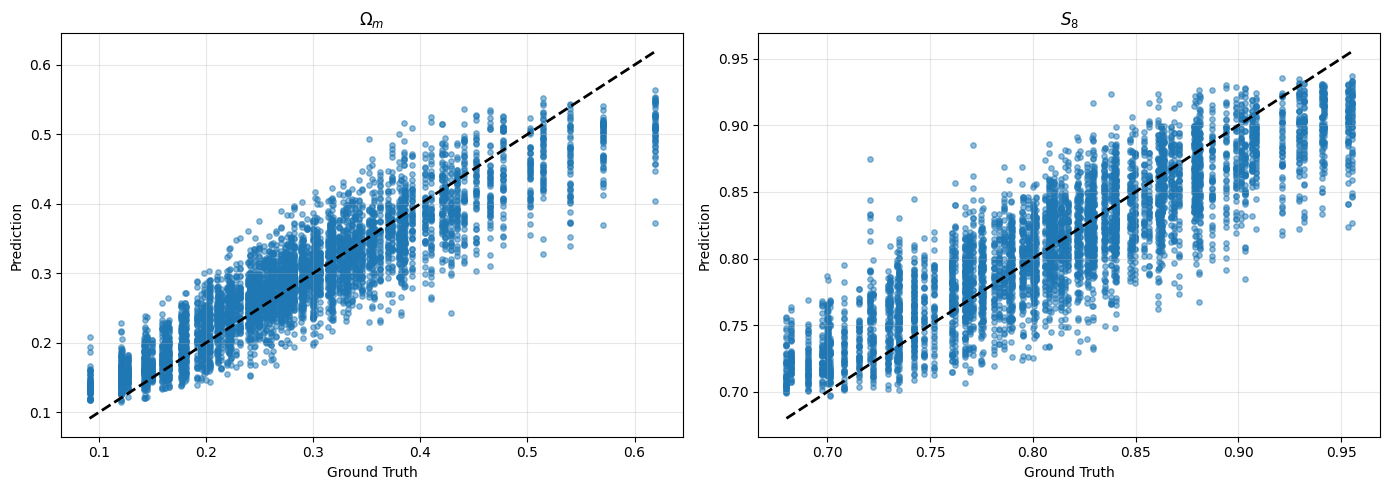

In [29]:
print("Evaluating on validation set...")

# Compute metrics
mse_om = mean_squared_error(y_val[:, 0], y_pred_val_qrf[:, 0])
mse_s8 = mean_squared_error(y_val[:, 1], y_pred_val_qrf[:, 1])
r2_om = r2_score(y_val[:, 0], y_pred_val_qrf[:, 0])
r2_s8 = r2_score(y_val[:, 1], y_pred_val_qrf[:, 1])

print(f"Ωₘ - MSE: {mse_om:.6f}, R²: {r2_om:.4f}")
print(f"S₈ - MSE: {mse_s8:.6f}, R²: {r2_s8:.4f}")

# Compute competition score
validation_score = Score._score_phase1(y_val, y_pred_val_qrf, errorbar_val_qrf_calibrated)
print(f"Validation Score: {validation_score:.2f}")

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_val[:, 0], y_pred_val_qrf[:, 0], alpha=0.5, s=15)
axes[0].plot(sorted(y_val[:, 0]), sorted(y_val[:, 0]), 'k--', linewidth=2)
axes[0].set_xlabel('Ground Truth')
axes[0].set_ylabel('Prediction')
axes[0].set_title(r'$\Omega_m$')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_val[:, 1], y_pred_val_qrf[:, 1], alpha=0.5, s=15)
axes[1].plot(sorted(y_val[:, 1]), sorted(y_val[:, 1]), 'k--', linewidth=2)
axes[1].set_xlabel('Ground Truth')
axes[1].set_ylabel('Prediction')
axes[1].set_title(r'$S_8$')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
validation_score = Score._score_phase1(y_val, y_pred_val_qrf, errorbar_val_qrf)
print(f"Validation Score: {validation_score:.2f}")

Validation Score: 1.66


In [32]:
print("Generating final test predictions...")

# Create submission data
data_submission = {
    "means": y_pred_test_qrf.tolist(),
    "errorbars": errorbar_test_qrf_calibrated.tolist()
}

timestamp = datetime.datetime.now().strftime("%y-%m-%d-%H-%M")
zip_file_name = f'Submission_ResNet_RF_{timestamp}.zip'

zip_file = Utility.save_json_zip(
    submission_dir="submissions",
    json_file_name="result.json",
    zip_file_name=zip_file_name,
    data=data_submission
)

print("\n" + "=" * 70)
print("RESNET + RANDOM FOREST SUBMISSION CREATED")
print("=" * 70)
print(f"File: {zip_file}")
print(f"Test samples: {len(y_pred_test_qrf)}")
print(f"Features used: {config.TOTAL_FEATURE_DIM}")
print(f"  ├── CNN features: {config.CNN_FEATURE_DIM}")
print(f"  ├── Power spectrum: {config.POWER_SPECTRUM_DIM}")
print(f"  ├── Peak statistics: {config.PEAK_STATS_DIM}")
print(f"  ├── Minkowski functionals: {config.MINKOWSKI_DIM}")
print(f"  ├── Wavelet coefficients: {config.WAVELET_DIM}")
print(f"  ├── Moment statistics: {config.MOMENT_DIM}")
print(f"  └── Correlation functions: {config.CORRELATION_DIM}")
print(f"Random Forest: {config.RF_N_ESTIMATORS} trees, min_samples_leaf={config.RF_MIN_SAMPLES_LEAF}")
print(f"Quantile Regression Forest: Calibrated error bars")
print("=" * 70)

Generating final test predictions...

RESNET + RANDOM FOREST SUBMISSION CREATED
File: submissions/Submission_ResNet_RF_25-11-13-00-10.zip
Test samples: 4000
Features used: 498
  ├── CNN features: 256
  ├── Power spectrum: 50
  ├── Peak statistics: 20
  ├── Minkowski functionals: 12
  ├── Wavelet coefficients: 100
  ├── Moment statistics: 30
  └── Correlation functions: 30
Random Forest: 2000 trees, min_samples_leaf=2
Quantile Regression Forest: Calibrated error bars
